# Analyse exploratoire des données (EDA)
**Projet : Contrôle qualité des données Proxima**

Ce notebook documente l'analyse de départ effectuée avant l'écriture du pipeline.
Il permet de comprendre la structure, la qualité et les particularités des données sources.

---

## 1. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid", palette="muted")

## 2. Chargement du fichier CSV

In [4]:
# Adapter le chemin selon l'environnement
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
INPUT_DIR = DATA_DIR / "inputs"
REF_DIR = DATA_DIR / "references"

CSV_PATH = INPUT_DIR / "export_Saas_2026-03-03 1.csv"

df = pd.read_csv(CSV_PATH, sep=";", engine='python')
print(f"Fichier chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Fichier chargé : 412422 lignes × 154 colonnes


In [6]:
CDPF_PATH = REF_DIR / "codes_postaux_france.csv"
cdpf = pd.read_csv(CDPF_PATH, sep=";", encoding="LATIN9")
cdpf.head()

,#Code_commune_INSEE,Nom_de_la_commune,Code_postal,Libellé_d_acheminement,Ligne_5
0,01001,L ABERGEMENT CLEMENCIAT,1400,L ABERGEMENT CLEMENCIAT,NaN
1,01002,L ABERGEMENT DE VAREY,1640,L ABERGEMENT DE VAREY,NaN
2,01004,AMBERIEU EN BUGEY,1500,AMBERIEU EN BUGEY,NaN
3,01005,AMBERIEUX EN DOMBES,1330,AMBERIEUX EN DOMBES,NaN
4,01006,AMBLEON,1300,AMBLEON,NaN


## 3. Structure générale

In [12]:
print("=== DIMENSIONS ===")
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print()
print("=== TYPES DE DONNÉES ===")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype} : {count} colonne(s)")

=== DIMENSIONS ===
Lignes   : 412422
Colonnes : 154

=== TYPES DE DONNÉES ===
  object : 100 colonne(s)
  float64 : 51 colonne(s)
  int64 : 3 colonne(s)


In [13]:
# Aperçu des premières lignes
df.head(5)

,id,marche,SOURCE,DT_UPDATE,DT_ARRETE,NU_CNT,NOM_CLI,CD_INT_STC,CD_PRD,PTGST,DT_EFF_AFN_CNT,DT_EFF_RESIL_CNT,DT_ECH_AN_CNT,CD_APERIT,TXACPT,INDICE_CNT,NBRE_SITES,CDSIREN,CDTRE_CNT,CDNAF,LCI_G,RESEAU,NM_INT,INTERNATIONAL,SOUS_LIMITE_EV_NAT,MONTANT,SOUS_LIMITE,COMMENTAIRE,BATCH,DICID,ID_SITE,NOM_SITE,DT_MAJ_SITE,DATE_VISITE_SITE,STOCK,CDTRE_1,CDNAF_1,CD_SIRET,QUALITE_JURID,USAGE,TYPE_BIEN,TYPE_RESIDENCE,ETAGE,EXCL_RISQ_LOCATIFS,EXCL_RISQ_BAT,NB_PIECE,SURFACE,SURFACE_DPDCE,PRIME_TTC,PRIME_PTF_ANN_HT,BATIMENT_CLASSE,BATIMENT_OCCUPE,PISCINES,HOTEL_NB_ETOILES,HOTEL_RESTAURANT,HOTEL_NB_CHB,LCI_BAT_CLASSE,LCI_GRD_RISQ,LCI_DEPENDANCE,DATE_EFFET_CAPITAUX,INDICE_CAPITAUX_MURS_BATIMENTS,CAPITAUX_MURS_BATIMENTS,CONTENU,INDICE_CAPITAUX_CONTENU,CAPITAUX_CONTENU,INDICE_CAPITAUX_MATERIELS,CAPITAUX_MATERIEL,INDICE_CAPITAUX_MARCHANDISES,CAPITAUX_MARCHANDISES,INDICE_CAPITAUX_ASS_MH_HLL_CARAV,CAPITAUX_ASS_MH_HLL_CARAV,INDICE_CAPITAUX_DEPENDANCE,CAPITAUX_DEPENDANCE,INDICE_CAPITAUX_COMPL,CAPITAUX_COMPL,INDICE_CAPITAUX_DD,CAPITAUX_DD,MARGE_BRUTE,PERIODE_INDEM_PE,CHIFFAFF_SITE,PERTE_LOYER,INDICE_VAL_PE,VAL_PE,SMP_INITIAL,LCI_GLOB,LCI_ATTENTAT,FRANCHISE_GLOB,UNI_FRAN_GLOB,MIN_FRAN_GLOB,MAX_FRAN_GLOB,FRANCHISE_INC,UNI_FRAN_INC,FRANCHISE_DDE,UNI_FRAN_DDE,FRANCHISE_PE,UNI_FRAN_PE,LIMITE_TGN,FRANCHISE_TGN,UNI_FRAN_TGN,MIN_FRAN_TGN,MAX_FRAN_TGN,NUM_VOIE_SITE,RUE_SITE,NUM_RUE_SITE,LIEU_DIT_SITE,CP_SITE,VILLE_SITE,ADRESSE_SITE,PAYS_SITE,COORD_X_SITE,COORD_Y_SITE,QUALITE_GEOCODAGE,LIMITE_INOND,FRANCHISE_INOND,UNI_FRAN_INOND,LIMITE_TREMB,FRANCHISE_TREMB,UNI_FRAN_TREMB,LIMITE_EMEUTES,FRANCHISE_EMEUTES,UNI_FRAN_EMEUTES,LIMITE_TOC,FRANCHISE_TOC,UNI_FRAN_TOC,TYPE_SITE,CEDANTE,ID_GAREAT,APERITEUR,NOM_APERITEUR,POL_APERITEUR,CD_SIREN_SIRET,CDNAF_GAREAT,LIBNAF_GAREAT,CDSIC,LIBSIC,TX_DEROG_ATT,LCI_MULTISITE,CAPITAUX_TT,RSQ_NUCLEAIRE,RSQ_SEVESO,TRC_TRME,MULTI_SITE,PORTEE_LIGNE,CD_GAR_CAR_FOURNIS,GAR_CAR_FOURNIS,CAR_FOURNIS_NNDENOM,CAR_FOURNIS_ENERGIE,CD_CAR_CLIENT,CAR_CLIENT,CAR_CLIENT_NNDENOM,CAR_CLIENT_ENERGIE,COM_GAREAT,CD_LC360,DICID_SITE
0,NaN,NaN,IMS,2020-03-31,2026-03-03,59375444,SOC RAIGI,4A1318,640,N30,2018-07-01,NaN,0701,A,100.00,NaN,0,712013424,*320,NaN,0.00,COURTAGE,GRAS SAVOYE,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,IMS,2020-03-31,2026-03-03,56066075,OR BRUN,152669,1065,N20,2016-01-01,NaN,0101,A,100.00,NaN,0,324632405,*305,NaN,0.00,COURTAGE,BERGER ASSURANCES,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,IMS,2020-03-31,2026-03-03,59788408,NS RAIL,H93065,1072,N23,2018-10-12,NaN,0101,A,100.00,NaN,0,842753709,NaN,NaN,0.00,AGENCE,MONTPELLIER EUROPE,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

## 4. Répartition par marché

Le fichier CSV contient plusieurs sous-ensembles de données selon le champ `marche`.
Il est important de les identifier car ils peuvent avoir des structures différentes.

=== RÉPARTITION PAR MARCHÉ ===
marche
PART      196649
RI&GAR    120121
IMM        76252
PROF        9851
NaN         9549
Name: count, dtype: int64


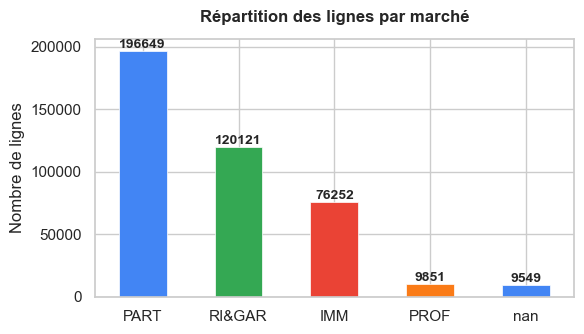

In [14]:
marche_counts = df['marche'].value_counts(dropna=False)
print("=== RÉPARTITION PAR MARCHÉ ===")
print(marche_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ['#4285f4', '#34a853', '#ea4335', '#fa7b17']
marche_counts.plot(kind='bar', ax=ax, color=colors[:len(marche_counts)], edgecolor='white', linewidth=0.5)
ax.set_title("Répartition des lignes par marché", fontweight='bold', pad=12)
ax.set_xlabel("")
ax.set_ylabel("Nombre de lignes")
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Analyse du filtre contrats actifs

Deux colonnes permettent d'identifier les contrats actifs :
- `STOCK = 1` → site en portefeuille
- `DT_EFF_RESIL_CNT` vide → contrat non résilié

> ⚠️ La colonne `CDSITP` (statut définitif) n'est pas dans le CSV — elle vient du datamart.

In [15]:
print("=== STOCK ===")
print(df['STOCK'].value_counts(dropna=False))
print()
print("=== DT_EFF_RESIL_CNT ===")
print(df['DT_EFF_RESIL_CNT'].value_counts(dropna=False))
print()

# Application du filtre
df_active = df[
    (df['STOCK'] == 1) &
    (df['DT_EFF_RESIL_CNT'].isna())
].copy()

print(f"=== RÉSULTAT DU FILTRE ===")
print(f"Avant filtre : {len(df)} lignes")
print(f"Après filtre : {len(df_active)} lignes actives")
print(f"Exclues      : {len(df) - len(df_active)} lignes")

=== STOCK ===
STOCK
1.00    409244
0.00      2569
NaN        609
Name: count, dtype: int64

=== DT_EFF_RESIL_CNT ===
DT_EFF_RESIL_CNT
NaN           364827
2022-01-01     14642
2026-01-01     12848
2023-01-01     10630
2023-12-31       974
               ...  
2019-07-15         1
2019-12-16         1
2019-08-19         1
2020-02-12         1
2019-04-16         1
Name: count, Length: 72, dtype: int64

=== RÉSULTAT DU FILTRE ===
Avant filtre : 412422 lignes
Après filtre : 361669 lignes actives
Exclues      : 50753 lignes


In [16]:
df.CP_SITE

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
          ...  
412417    93110
412418    13270
412419    34730
412420    34730
412421    86000
Name: CP_SITE, Length: 412422, dtype: object

## 6. Taux de remplissage des colonnes clés

On se concentre sur les 25 colonnes utilisées par le projet.

In [17]:
KEY_COLS = [
    # Identification
    'STOCK', 'DT_EFF_RESIL_CNT', 'NU_CNT', 'PTGST', 'ID_SITE', 'NOM_CLI', 'NOM_SITE', 'marche',
    # Adresse
    'NUM_VOIE_SITE', 'RUE_SITE', 'NUM_RUE_SITE', 'LIEU_DIT_SITE',
    'CP_SITE', 'VILLE_SITE', 'PAYS_SITE',
    # GPS
    'COORD_X_SITE', 'COORD_Y_SITE', 'QUALITE_GEOCODAGE',
    # Techniques
    'SURFACE', 'SURFACE_DPDCE',
    'CAPITAUX_MURS_BATIMENTS', 'CAPITAUX_CONTENU',
    'CAPITAUX_MATERIEL', 'CAPITAUX_MARCHANDISES', 'CAPITAUX_TT'
]

fill_rates = []
for col in KEY_COLS:
    if col in df_active.columns:
        total = len(df_active)
        filled = df_active[col].notna().sum()
        rate = filled / total * 100 if total > 0 else 0
        fill_rates.append({'colonne': col, 'remplies': filled, 'total': total, 'taux_%': round(rate, 1)})

fill_df = pd.DataFrame(fill_rates).sort_values('taux_%', ascending=False)
fill_df

,colonne,remplies,total,taux_%
0,STOCK,361669,361669,100.00
2,NU_CNT,361669,361669,100.00
4,ID_SITE,361669,361669,100.00
5,NOM_CLI,361669,361669,100.00
13,VILLE_SITE,360178,361669,99.60
7,marche,359744,361669,99.50
14,PAYS_SITE,357879,361669,99.00
24,CAPITAUX_TT,357784,361669,98.90
12,CP_SITE,343954,361669,95.10
3,PTGST,308073,361669,85.20


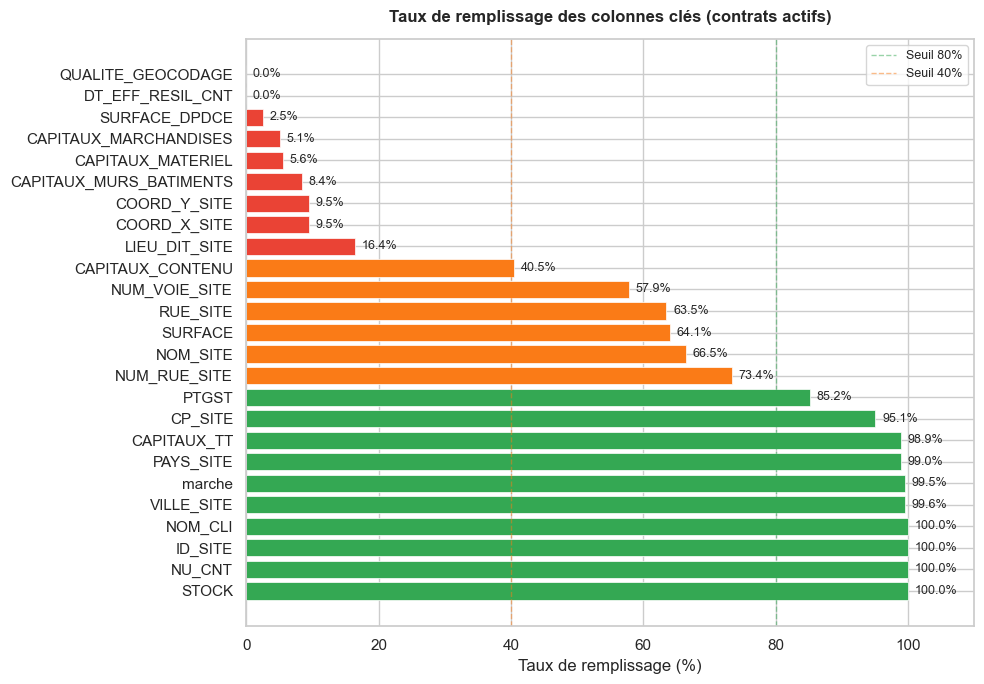


🟢 >= 80% | 🟠 40-80% | 🔴 < 40%


In [18]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#34a853' if x >= 80 else '#fa7b17' if x >= 40 else '#ea4335' for x in fill_df['taux_%']]
bars = ax.barh(fill_df['colonne'], fill_df['taux_%'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlim(0, 110)
ax.axvline(80, color='#34a853', linestyle='--', linewidth=1, alpha=0.5, label='Seuil 80%')
ax.axvline(40, color='#fa7b17', linestyle='--', linewidth=1, alpha=0.5, label='Seuil 40%')
for bar, val in zip(bars, fill_df['taux_%']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.set_title("Taux de remplissage des colonnes clés (contrats actifs)", fontweight='bold', pad=12)
ax.set_xlabel("Taux de remplissage (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n🟢 >= 80% | 🟠 40-80% | 🔴 < 40%")

## 7. Analyse des champs adresse

In [19]:
pays_counts = df['PAYS_SITE'].value_counts(dropna=False)
print("=== RÉPARTITION PAR PAYS ===")

pays_counts.reset_index()

=== RÉPARTITION PAR PAYS ===


,PAYS_SITE,count
0,FRANCE,337581
1,NaN,33756
2,France,24007
3,ITALIE,12813
4,ESPAGNE,568
...,...,...
118,NOUVELLE-ZÉLANDE,1
119,canada,1
120,Taiwan,1
121,Israël,1


In [20]:
addr_cols = ['NUM_VOIE_SITE', 'RUE_SITE', 'NUM_RUE_SITE', 'LIEU_DIT_SITE', 'CP_SITE', 'VILLE_SITE', 'PAYS_SITE']

print("=== VALEURS MANQUANTES PAR CHAMP ADRESSE ===")
for col in addr_cols:
    if col in df_active.columns:
        missing = df_active[col].isna().sum()
        total = len(df_active)
        print(f"  {col:<22} : {missing}/{total} manquants ({missing/total*100:.1f}%)")

print()
print("=== PAYS_SITE — valeurs distinctes ===")
print(df_active['PAYS_SITE'].value_counts(dropna=False))

=== VALEURS MANQUANTES PAR CHAMP ADRESSE ===
  NUM_VOIE_SITE          : 152255/361669 manquants (42.1%)
  RUE_SITE               : 132146/361669 manquants (36.5%)
  NUM_RUE_SITE           : 96305/361669 manquants (26.6%)
  LIEU_DIT_SITE          : 302465/361669 manquants (83.6%)
  CP_SITE                : 17715/361669 manquants (4.9%)
  VILLE_SITE             : 1491/361669 manquants (0.4%)
  PAYS_SITE              : 3790/361669 manquants (1.0%)

=== PAYS_SITE — valeurs distinctes ===
PAYS_SITE
FRANCE                327639
France                 13761
ITALIE                 12806
NaN                     3790
ESPAGNE                  539
                       ...  
République tchèque         1
Pays de Galles             1
NOUVELLE-ZÉLANDE           1
ESTONIE                    1
GUYANE                     1
Name: count, Length: 101, dtype: int64


In [21]:
# CP_SITE — problème du zéro initial
print("=== CP_SITE — exemples de valeurs brutes ===")
print(df_active['CP_SITE'].dropna().head(15).tolist())

=== CP_SITE — exemples de valeurs brutes ===
['57150', '57520', '57200', '57430', '33500', '85440', '29000', '51100', '74110', '22300', '09400', '29870', '29470', '35530', '29770']


In [22]:
# Redondance RUE_SITE vs NUM_RUE_SITE
print("=== Redondance RUE_SITE vs NUM_RUE_SITE ===")
both_filled = df_active['RUE_SITE'].notna() & df_active['NUM_RUE_SITE'].notna()
only_rue    = df_active['RUE_SITE'].notna() & df_active['NUM_RUE_SITE'].isna()
only_num    = df_active['RUE_SITE'].isna()  & df_active['NUM_RUE_SITE'].notna()
both_empty  = df_active['RUE_SITE'].isna()  & df_active['NUM_RUE_SITE'].isna()

print(f"  Les deux renseignés    : {both_filled.sum()}")
print(f"  RUE_SITE seul          : {only_rue.sum()}")
print(f"  NUM_RUE_SITE seul      : {only_num.sum()}")
print(f"  Les deux vides         : {both_empty.sum()}")
print()
print("Exemples où les deux sont renseignés :")
df_active[both_filled][['RUE_SITE','NUM_RUE_SITE']].head(5)

=== Redondance RUE_SITE vs NUM_RUE_SITE ===
  Les deux renseignés    : 190394
  RUE_SITE seul          : 39129
  NUM_RUE_SITE seul      : 74970
  Les deux vides         : 57176

Exemples où les deux sont renseignés :


,RUE_SITE,NUM_RUE_SITE
513,rue du Chateau,9 rue du Chateau
514,place Terre au Duc,4 place Terre au Duc
586,Route De Rostrenen,105 Route De Rostrenen
587,Route D'arignac,Route D'arignac
588,D28,D28


## 8. Analyse des coordonnées GPS

In [23]:
gps_cols = ['COORD_X_SITE', 'COORD_Y_SITE', 'QUALITE_GEOCODAGE']
print("=== REMPLISSAGE GPS ===")
for col in gps_cols:
    filled = df_active[col].notna().sum()
    print(f"  {col:<22} : {filled}/{len(df_active)} renseignés")

print()
# Cas où GPS est vide mais adresse présente (scénario A — valide)
has_address = df_active['CP_SITE'].notna() & df_active['VILLE_SITE'].notna()
no_gps      = df_active['COORD_X_SITE'].isna() | df_active['COORD_Y_SITE'].isna()
has_gps     = df_active['COORD_X_SITE'].notna() & df_active['COORD_Y_SITE'].notna()

print(f"Scénario A (adresse ✅, GPS absent) : {(has_address & no_gps).sum()} lignes → VALIDE")
print(f"Scénario B (adresse ✅, GPS ✅)     : {(has_address & has_gps).sum()} lignes → à vérifier cohérence")
print(f"Scénario C (adresse ❌, GPS ✅)     : {(~has_address & has_gps).sum()} lignes → à vérifier pays")
print(f"Cas dégénéré (adresse ❌, GPS ❌)   : {(~has_address & ~has_gps).sum()} lignes → anomalie grave")

=== REMPLISSAGE GPS ===
  COORD_X_SITE           : 34342/361669 renseignés
  COORD_Y_SITE           : 34515/361669 renseignés
  QUALITE_GEOCODAGE      : 168/361669 renseignés

Scénario A (adresse ✅, GPS absent) : 309386 lignes → VALIDE
Scénario B (adresse ✅, GPS ✅)     : 34203 lignes → à vérifier cohérence
Scénario C (adresse ❌, GPS ✅)     : 139 lignes → à vérifier pays
Cas dégénéré (adresse ❌, GPS ❌)   : 17941 lignes → anomalie grave


## 9. Analyse des données techniques (capitaux & superficie)

In [24]:
tech_cols = [
    'SURFACE', 'SURFACE_DPDCE',
    'CAPITAUX_MURS_BATIMENTS', 'CAPITAUX_CONTENU',
    'CAPITAUX_MATERIEL', 'CAPITAUX_MARCHANDISES', 'CAPITAUX_TT'
]

df_active[tech_cols]

,SURFACE,SURFACE_DPDCE,CAPITAUX_MURS_BATIMENTS,CAPITAUX_CONTENU,CAPITAUX_MATERIEL,CAPITAUX_MARCHANDISES,CAPITAUX_TT
136,NaN,NaN,2482261,0,3971618,322819,0
138,NaN,NaN,4274840,0,0,0,5225000
139,NaN,NaN,3500000,0,0,0,0
141,NaN,NaN,0,NaN,200000,200000,0
511,310,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
412417,0,NaN,NaN,NaN,NaN,NaN,0
412418,0,NaN,NaN,NaN,NaN,NaN,0
412419,0,NaN,NaN,NaN,NaN,NaN,0
412420,0,NaN,NaN,NaN,NaN,NaN,0


In [25]:
tech_cols = [
    'SURFACE', 'SURFACE_DPDCE',
    'CAPITAUX_MURS_BATIMENTS', 'CAPITAUX_CONTENU',
    'CAPITAUX_MATERIEL', 'CAPITAUX_MARCHANDISES', 'CAPITAUX_TT'
]

def to_numeric_series(s):
    # si besoin, adapte le nettoyage (virgules, espaces, etc.)
    return pd.to_numeric(s, errors='coerce')

print("=== REMPLISSAGE DONNÉES TECHNIQUES ===")
for col in tech_cols:
    if col in df_active.columns:
        s_num = to_numeric_series(df_active[col])
        filled   = s_num.notna().sum()
        non_zero = (s_num.fillna(0) > 0).sum()
        print(f"  {col:<35} : {filled}/{len(df_active)} renseignés, {non_zero} non nuls")

print()

# Conversion numérique pour les règles
surf_num   = to_numeric_series(df_active['SURFACE'])
mur_num    = to_numeric_series(df_active['CAPITAUX_MURS_BATIMENTS'])
cont_num   = to_numeric_series(df_active['CAPITAUX_CONTENU'])
mat_num    = to_numeric_series(df_active['CAPITAUX_MATERIEL'])
march_num  = to_numeric_series(df_active['CAPITAUX_MARCHANDISES'])

has_surface = (surf_num.fillna(0) > 0) | (df_active['SURFACE_DPDCE'].fillna(0) > 0)
has_capitaux = (
    (mur_num.fillna(0) > 0) |
    (cont_num.fillna(0) > 0) |
    (mat_num.fillna(0) > 0) |
    (march_num.fillna(0) > 0)
)

has_tech = has_surface | has_capitaux
missing_tech = ~has_tech

print(f"Lignes avec au moins 1 donnée technique : {has_tech.sum()}/{len(df_active)}")
print(f"Lignes SANS aucune donnée technique     : {missing_tech.sum()}/{len(df_active)} ← anomalie R5")


=== REMPLISSAGE DONNÉES TECHNIQUES ===
  SURFACE                             : 231677/361669 renseignés, 214226 non nuls
  SURFACE_DPDCE                       : 9195/361669 renseignés, 1755 non nuls
  CAPITAUX_MURS_BATIMENTS             : 29698/361669 renseignés, 17197 non nuls
  CAPITAUX_CONTENU                    : 146214/361669 renseignés, 124874 non nuls
  CAPITAUX_MATERIEL                   : 20340/361669 renseignés, 12100 non nuls
  CAPITAUX_MARCHANDISES               : 17606/361669 renseignés, 8473 non nuls
  CAPITAUX_TT                         : 357758/361669 renseignés, 72494 non nuls

Lignes avec au moins 1 donnée technique : 278062/361669
Lignes SANS aucune donnée technique     : 83607/361669 ← anomalie R5


=== CAPITAUX_CONTENU — statistiques ===
count     146557
unique      8919
top            0
freq       21340
Name: CAPITAUX_CONTENU, dtype: object


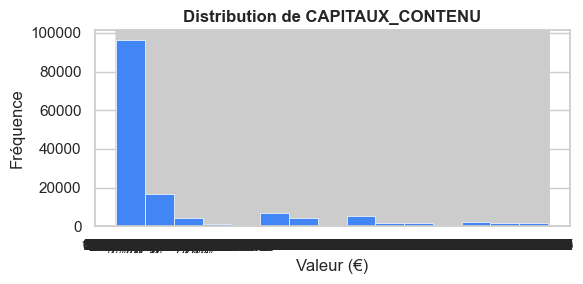

In [26]:
# Distribution de CAPITAUX_CONTENU (seul capital renseigné dans l'échantillon)
cap = df_active['CAPITAUX_CONTENU'].dropna()
if len(cap) > 0:
    print("=== CAPITAUX_CONTENU — statistiques ===")
    print(cap.describe())
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(cap, bins=15, color='#4285f4', edgecolor='white', linewidth=0.5)
    ax.set_title("Distribution de CAPITAUX_CONTENU", fontweight='bold')
    ax.set_xlabel("Valeur (€)")
    ax.set_ylabel("Fréquence")
    plt.tight_layout()
    plt.show()
else:
    print("CAPITAUX_CONTENU vide dans cet échantillon.")

## 10. Statut juridique (QUALITE_JURID)

In [27]:
print("=== QUALITE_JURID — valeurs distinctes ===")
print(df_active['QUALITE_JURID'].value_counts(dropna=False))
print()
print("⚠️ Valeur 'L' semble non normalisée par rapport à 'LOC' — à clarifier avec Alain.")

=== QUALITE_JURID — valeurs distinctes ===
QUALITE_JURID
PNO                     115965
NaN                      93739
LOC                      86845
NR                       32286
PRO                      27626
COP                       1886
AUT                        883
SCP                        712
L                          501
PO                         360
LOP                        263
LAC                        216
CNO                        182
LT                          60
P                           36
A                           29
LTO                         26
LOCATAIRE TOTAL             16
Locataire total              9
LP                           7
SCI                          6
LOM                          6
LOCATAIRE-GERANT             4
LOG                          3
T                            1
0                            1
COPROPRIETAIRE non o         1
Name: count, dtype: int64

⚠️ Valeur 'L' semble non normalisée par rapport à 'LOC' — à clarifier avec Alai